# Milestone 1: Augmentation Comparison

この notebook では augmentation ごとの効き方と壊れ方を比較します。

ここで理解したいこと:
- augmentation は増やせばよいわけではない
- image だけでなく bbox も壊さない必要がある
- どの augmentation が何に効きやすいか、目で比較するのが大切

In [9]:
import sys
from pathlib import Path

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.append(str(src_root))

from processing import build_category_index, group_annotations_by_image, load_coco_json, load_image_rgb, select_image_with_min_annotations
from processing.visualization import draw_bboxes

plt.rcParams["figure.figsize"] = (8, 8)

## 1. データを読む

ここでは COCO `val2017` を使って、bbox を持つ画像 1 枚を比較対象にします。

In [10]:
coco_root = project_root / "data" / "coco"
images_dir = coco_root / "val2017"
instances_path = coco_root / "annotations" / "instances_val2017.json"

coco_instances = load_coco_json(instances_path)
annotations_by_image = group_annotations_by_image(coco_instances)
categories_by_id = build_category_index(coco_instances)
selected_image_info, selected_annotations = select_image_with_min_annotations(coco_instances, annotations_by_image, min_annotations=3)
image = load_image_rgb(images_dir / selected_image_info["file_name"])

print(selected_image_info)
print(f"num_annotations: {len(selected_annotations)}")

{'license': 4, 'file_name': '000000397133.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-14 17:02:52', 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg', 'id': 397133}
num_annotations: 19


In [11]:
def show_images(image_map: dict[str, np.ndarray], cols: int = 2) -> None:
    items = list(image_map.items())
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (title, image_item) in zip(axes, items):
        ax.imshow(image_item)
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def run_bbox_transform(transform: A.Compose, image: np.ndarray, annotations: list[dict]) -> tuple[np.ndarray, list[dict]]:
    input_bboxes = [ann["bbox"] for ann in annotations]
    bbox_labels = [categories_by_id[ann["category_id"]]["name"] for ann in annotations]
    bbox_indices = list(range(len(annotations)))
    result = transform(image=image, bboxes=input_bboxes, bbox_labels=bbox_labels, bbox_indices=bbox_indices)
    transformed_annotations = []
    for bbox, ann_index in zip(result["bboxes"], result["bbox_indices"]):
        ann_index = int(ann_index)
        transformed_annotations.append({**annotations[ann_index], "bbox": list(bbox)})
    return result["image"], transformed_annotations

## 2. 比較したい augmentation を定義する

ここでは、初心者がまず理解しやすい augmentation を選びます。

- horizontal flip
- brightness / contrast
- gaussian blur
- affine
- coarse dropout

理解ポイント:
- photometric 系は bbox を動かさない
- geometric 系は bbox も同期変換が必要
- dropout 系は効くこともあるが、強すぎると対象を隠しすぎる

In [12]:
image_only_transforms = {
    "brightness_contrast": A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0),
    ]),
    "gaussian_blur": A.Compose([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
    ]),
    "coarse_dropout": A.Compose([
        A.CoarseDropout(num_holes_range=(4, 6), hole_height_range=(24, 48), hole_width_range=(24, 48), fill=0, p=1.0),
    ]),
}

bbox_transforms = {
    "horizontal_flip": A.Compose(
        [A.HorizontalFlip(p=1.0)],
        bbox_params=A.BboxParams(format="coco", label_fields=["bbox_labels", "bbox_indices"]),
    ),
    "affine": A.Compose(
        [A.Affine(scale=0.9, translate_percent={"x": 0.05, "y": 0.05}, rotate=12, p=1.0)],
        bbox_params=A.BboxParams(format="coco", label_fields=["bbox_labels", "bbox_indices"]),
    ),
}


## 3. image のみ変わる augmentation を比較する

目的:
- 見た目だけ変える augmentation の効き方を比べる

ここで見ること:
- 明るさ変化が強すぎないか
- blur が detail を消しすぎないか
- dropout が対象を隠しすぎないか

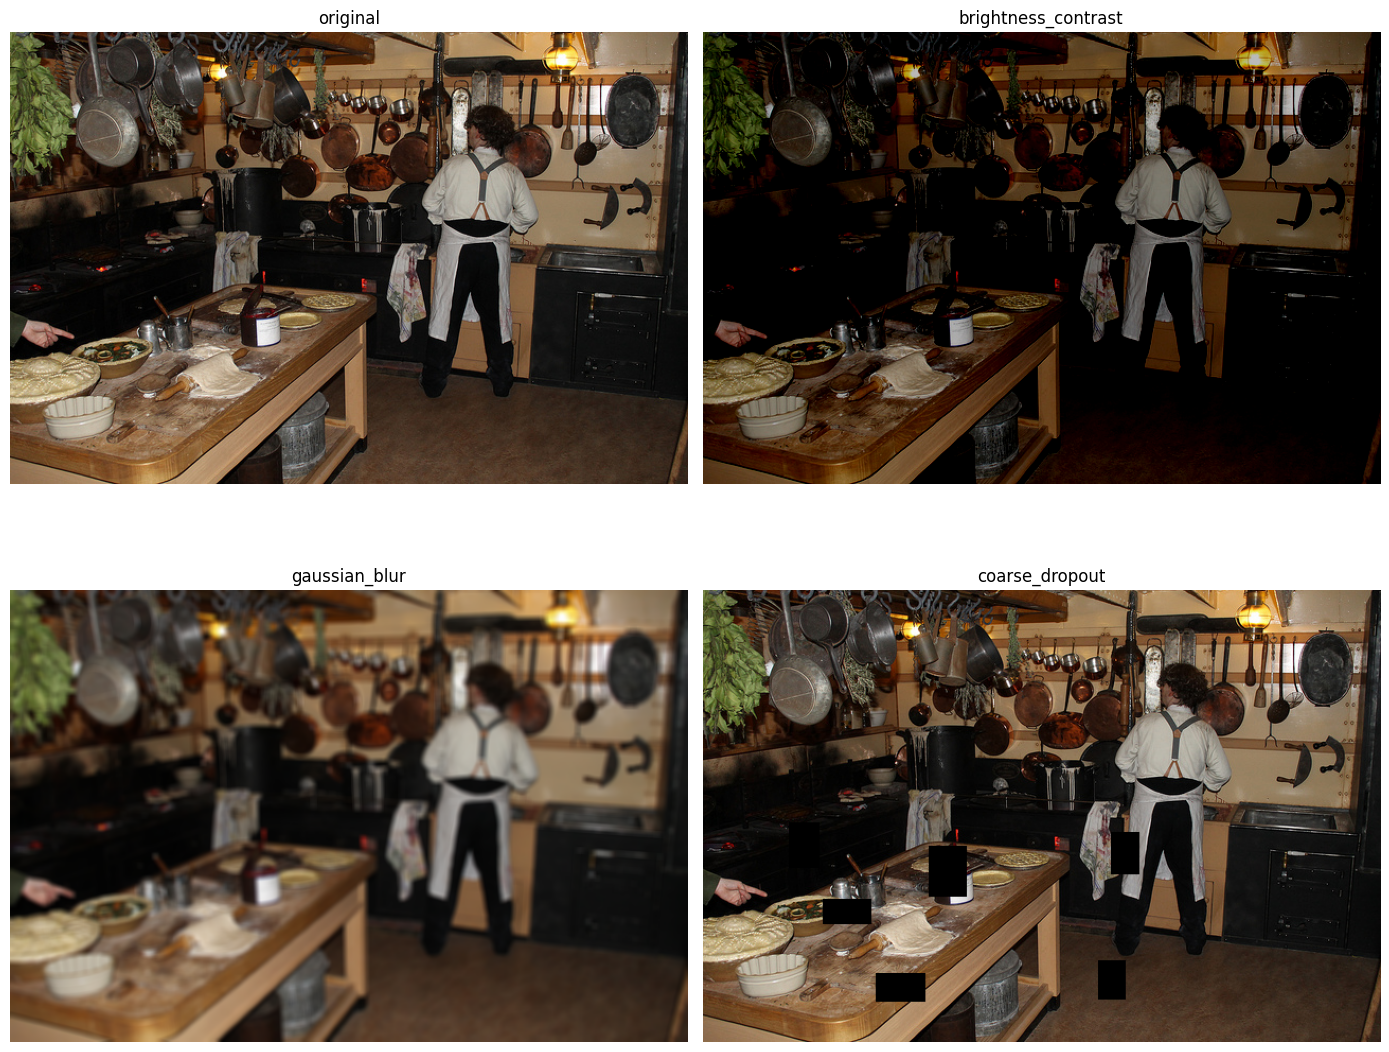

In [13]:
image_only_results = {"original": image}
for name, transform in image_only_transforms.items():
    image_only_results[name] = transform(image=image)["image"]

show_images(image_only_results, cols=2)

## 4. bbox 同期が必要な augmentation を比較する

目的:
- geometric augmentation では bbox 追従が必須だと理解する

ここで見ること:
- 反転後に bbox が左右逆へ正しく移動しているか
- affine 後に bbox がずれずに対象を囲めているか

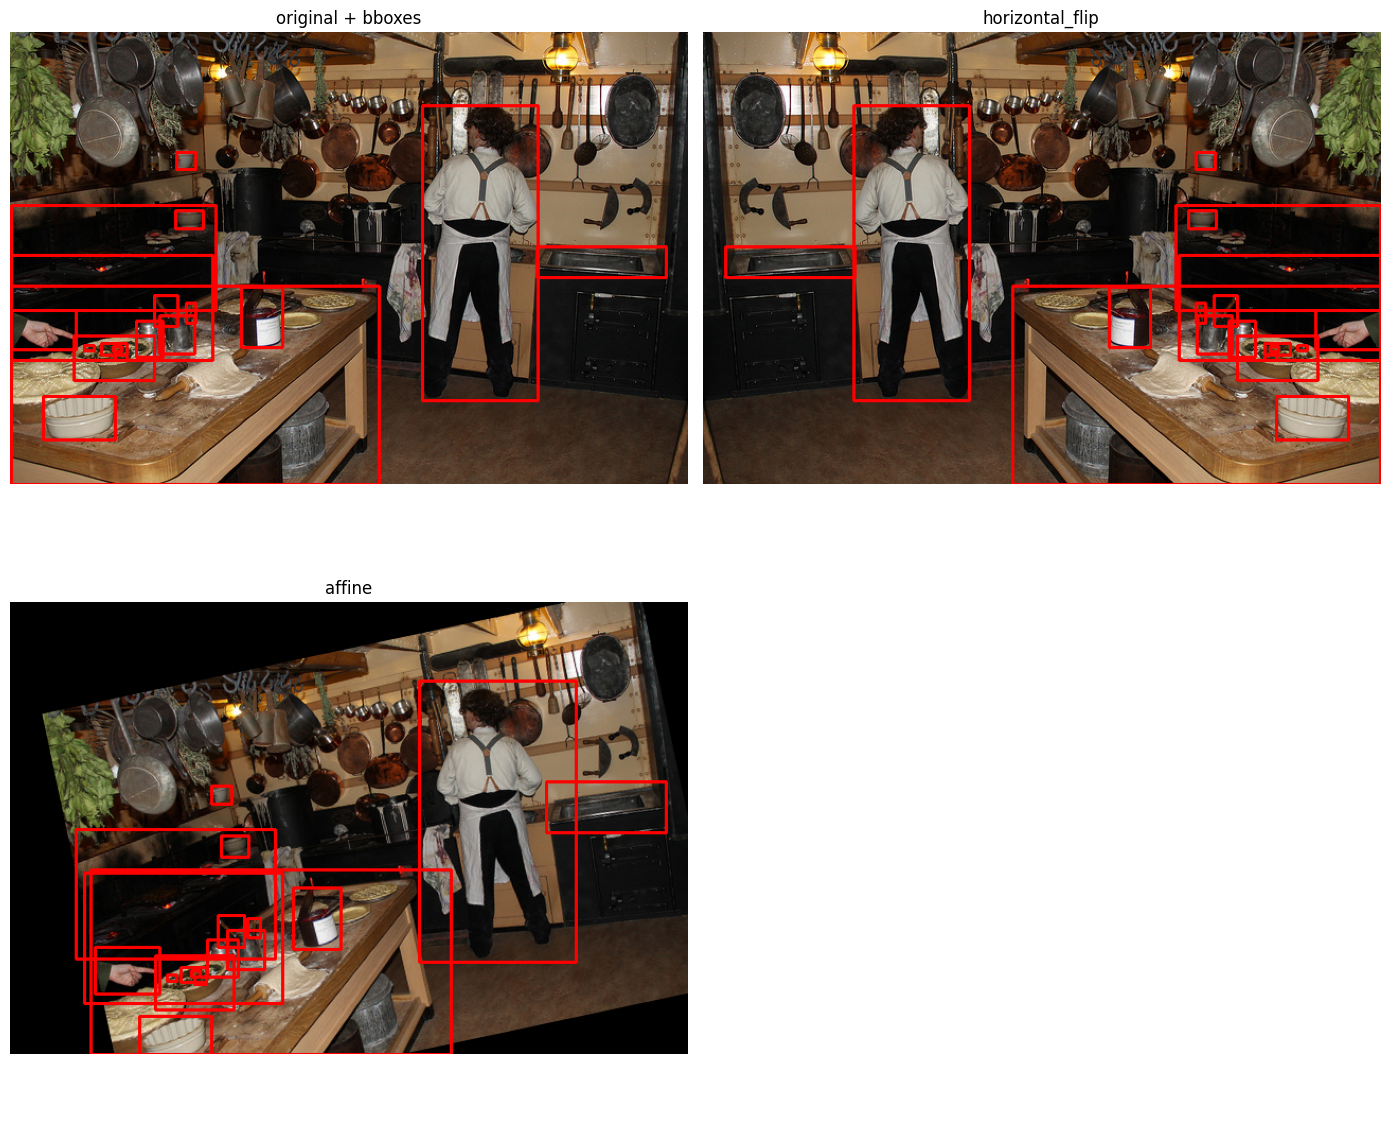

In [14]:
bbox_results = {"original + bboxes": draw_bboxes(image, selected_annotations)}
for name, transform in bbox_transforms.items():
    transformed_image, transformed_annotations = run_bbox_transform(transform, image, selected_annotations)
    bbox_results[name] = draw_bboxes(transformed_image, transformed_annotations)

show_images(bbox_results, cols=2)

## 5. augmentation の効き方と壊れ方を言語化する

この notebook の目的は、augmentation を増やすことではなく、良し悪しを説明できるようにすることです。

確認ポイント:
- brightness / contrast は照明ゆらぎへの耐性に効きやすい
- blur は画質劣化耐性に効くが、小物体には不利になりやすい
- flip は左右対称性がある対象には有効なことが多い
- affine は強すぎると bbox が不自然になったり、対象の意味が変わることがある
- coarse dropout は遮蔽耐性に効くことがあるが、重要部分を消しすぎることもある